In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Read File
df=pd.read_csv(r"D:\dataanalytics\Data\Data\auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [7]:
df.shape


(398, 9)

Observatio: there is 398 rows and 9 col


In [8]:
# Typecasting
df['horsepower']=pd.to_numeric(df['horsepower'],errors='coerce')
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [9]:
# Detecting noisy data
unique_values = {}

for col in df.columns:
    unique_values[col] = df[col].unique()

print(unique_values)

{'mpg': array([18. , 15. , 16. , 17. , 14. , 24. , 22. , 21. , 27. , 26. , 25. ,
       10. , 11. ,  9. , 28. , 19. , 12. , 13. , 23. , 30. , 31. , 35. ,
       20. , 29. , 32. , 33. , 17.5, 15.5, 14.5, 22.5, 24.5, 18.5, 29.5,
       26.5, 16.5, 31.5, 36. , 25.5, 33.5, 20.5, 30.5, 21.5, 43.1, 36.1,
       32.8, 39.4, 19.9, 19.4, 20.2, 19.2, 25.1, 20.6, 20.8, 18.6, 18.1,
       17.7, 27.5, 27.2, 30.9, 21.1, 23.2, 23.8, 23.9, 20.3, 21.6, 16.2,
       19.8, 22.3, 17.6, 18.2, 16.9, 31.9, 34.1, 35.7, 27.4, 25.4, 34.2,
       34.5, 31.8, 37.3, 28.4, 28.8, 26.8, 41.5, 38.1, 32.1, 37.2, 26.4,
       24.3, 19.1, 34.3, 29.8, 31.3, 37. , 32.2, 46.6, 27.9, 40.8, 44.3,
       43.4, 36.4, 44.6, 40.9, 33.8, 32.7, 23.7, 23.6, 32.4, 26.6, 25.8,
       23.5, 39.1, 39. , 35.1, 32.3, 37.7, 34.7, 34.4, 29.9, 33.7, 32.9,
       31.6, 28.1, 30.7, 24.2, 22.4, 34. , 38. , 44. ]), 'cylinders': array([8, 4, 6, 3, 5]), 'displacement': array([307. , 350. , 318. , 304. , 302. , 429. , 454. , 440. , 455. ,
       39

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation:
There is no duplicated values

In [11]:
# Detecting null values
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [12]:
# outliers are present thats why median is used
df['horsepower']=df['horsepower'].fillna(df['horsepower'].median())
df['horsepower']

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

In [13]:
# rechecking null value
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

# Detecting Outliers

In [27]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [29]:
Q1=df['mpg'].quantile(0.25)
Q1

np.float64(17.5)

In [30]:
Q3=df['mpg'].quantile(0.75)
Q3

np.float64(29.0)

In [31]:
IQR=Q3-Q1
IQR

np.float64(11.5)

In [32]:
LB=Q1-1.5*IQR
LB

np.float64(0.25)

In [33]:
UB=Q3+1.5*IQR
UB

np.float64(46.25)

In [39]:
df[(df['mpg']<LB )|(df['mpg']>UB)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
322,46.6,4,86.0,65.0,2110,17.9,80,3,mazda glc


# Handling outliers 
Removing outliers

In [40]:
df_clean=df[(df['mpg']>=LB)&(df['mpg']<=UB)]
df_clean

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [41]:
# Capping
df_cap=df.copy()
df_cap


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [42]:
df_cap['mpg'] = df['mpg'].apply(lambda x : LB if x < LB else UB if x > UB else x)
df_cap['mpg']

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [85]:
Q1=df['horsepower'].quantile(0.25)
Q1

np.float64(76.0)

In [86]:
Q3=df['horsepower'].quantile(0.75)
Q3

np.float64(125.0)

In [101]:
IQR=Q3-Q1
IQR
df_cap=df.copy()
df_cap
LB=Q1-1.5*IQR
UB=Q3+1.5*IQR

In [102]:
df_cap['horsepower'] = df['horsepower'].apply(lambda x : LB if x < LB else UB if x > UB else x)
df_cap['horsepower']

0      22.2
1      22.2
2      22.2
3      22.2
4      22.2
       ... 
393    22.2
394    22.2
395    22.2
396    22.2
397    22.2
Name: horsepower, Length: 398, dtype: float64

In [103]:
Q1=df['acceleration'].quantile(0.25)
Q3=df['acceleration'].quantile(0.75)
IQR=Q3-Q1
df_cap1=df.copy()
LB=Q1-1.5*IQR
UB=Q3+1.5*IQR

In [104]:
df_cap1['acceleration']=df_cap1['acceleration'].apply(lambda x:LB if x < LB else UB if x> UB else x)
df_cap1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,22.2,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


# Data Visualization

In [56]:
# Univariate analysis

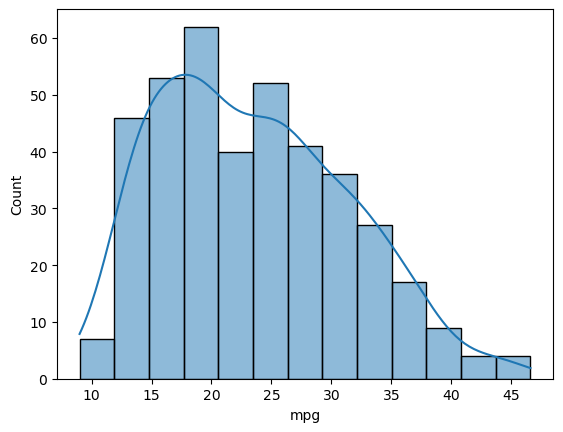

In [89]:
sns.histplot(data=df, x='mpg',kde=True)
plt.show()

# Insight
it shows distributution of mpg 

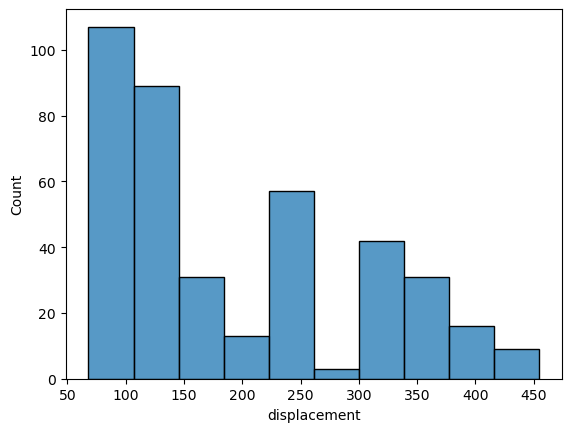

In [58]:
sns.histplot(data=df,x='displacement')
plt.show()

Insight:
The histogram reveals a mostly uniform distribution across the displacement,

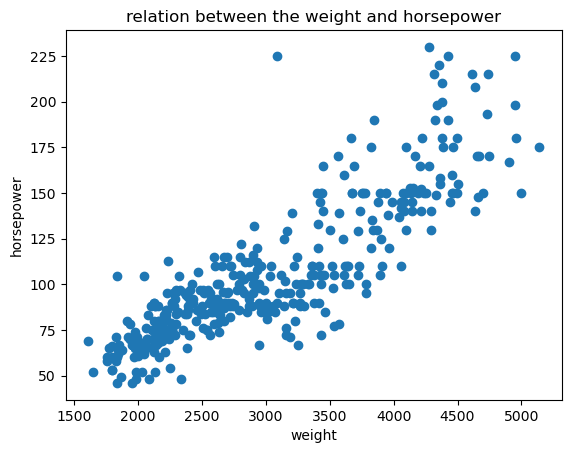

In [66]:
# Bivariate analysis
plt.scatter(df['weight'],df['horsepower'])
plt.title('relation between the weight and horsepower')
plt.xlabel('weight')
plt.ylabel('horsepower')
plt.show()

Observation: insight  is positive relation between in weight and horsepower

In [69]:
df_num=df.select_dtypes(include='number')
df_num

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1
394,44.0,4,97.0,52.0,2130,24.6,82,2
395,32.0,4,135.0,84.0,2295,11.6,82,1
396,28.0,4,120.0,79.0,2625,18.6,82,1


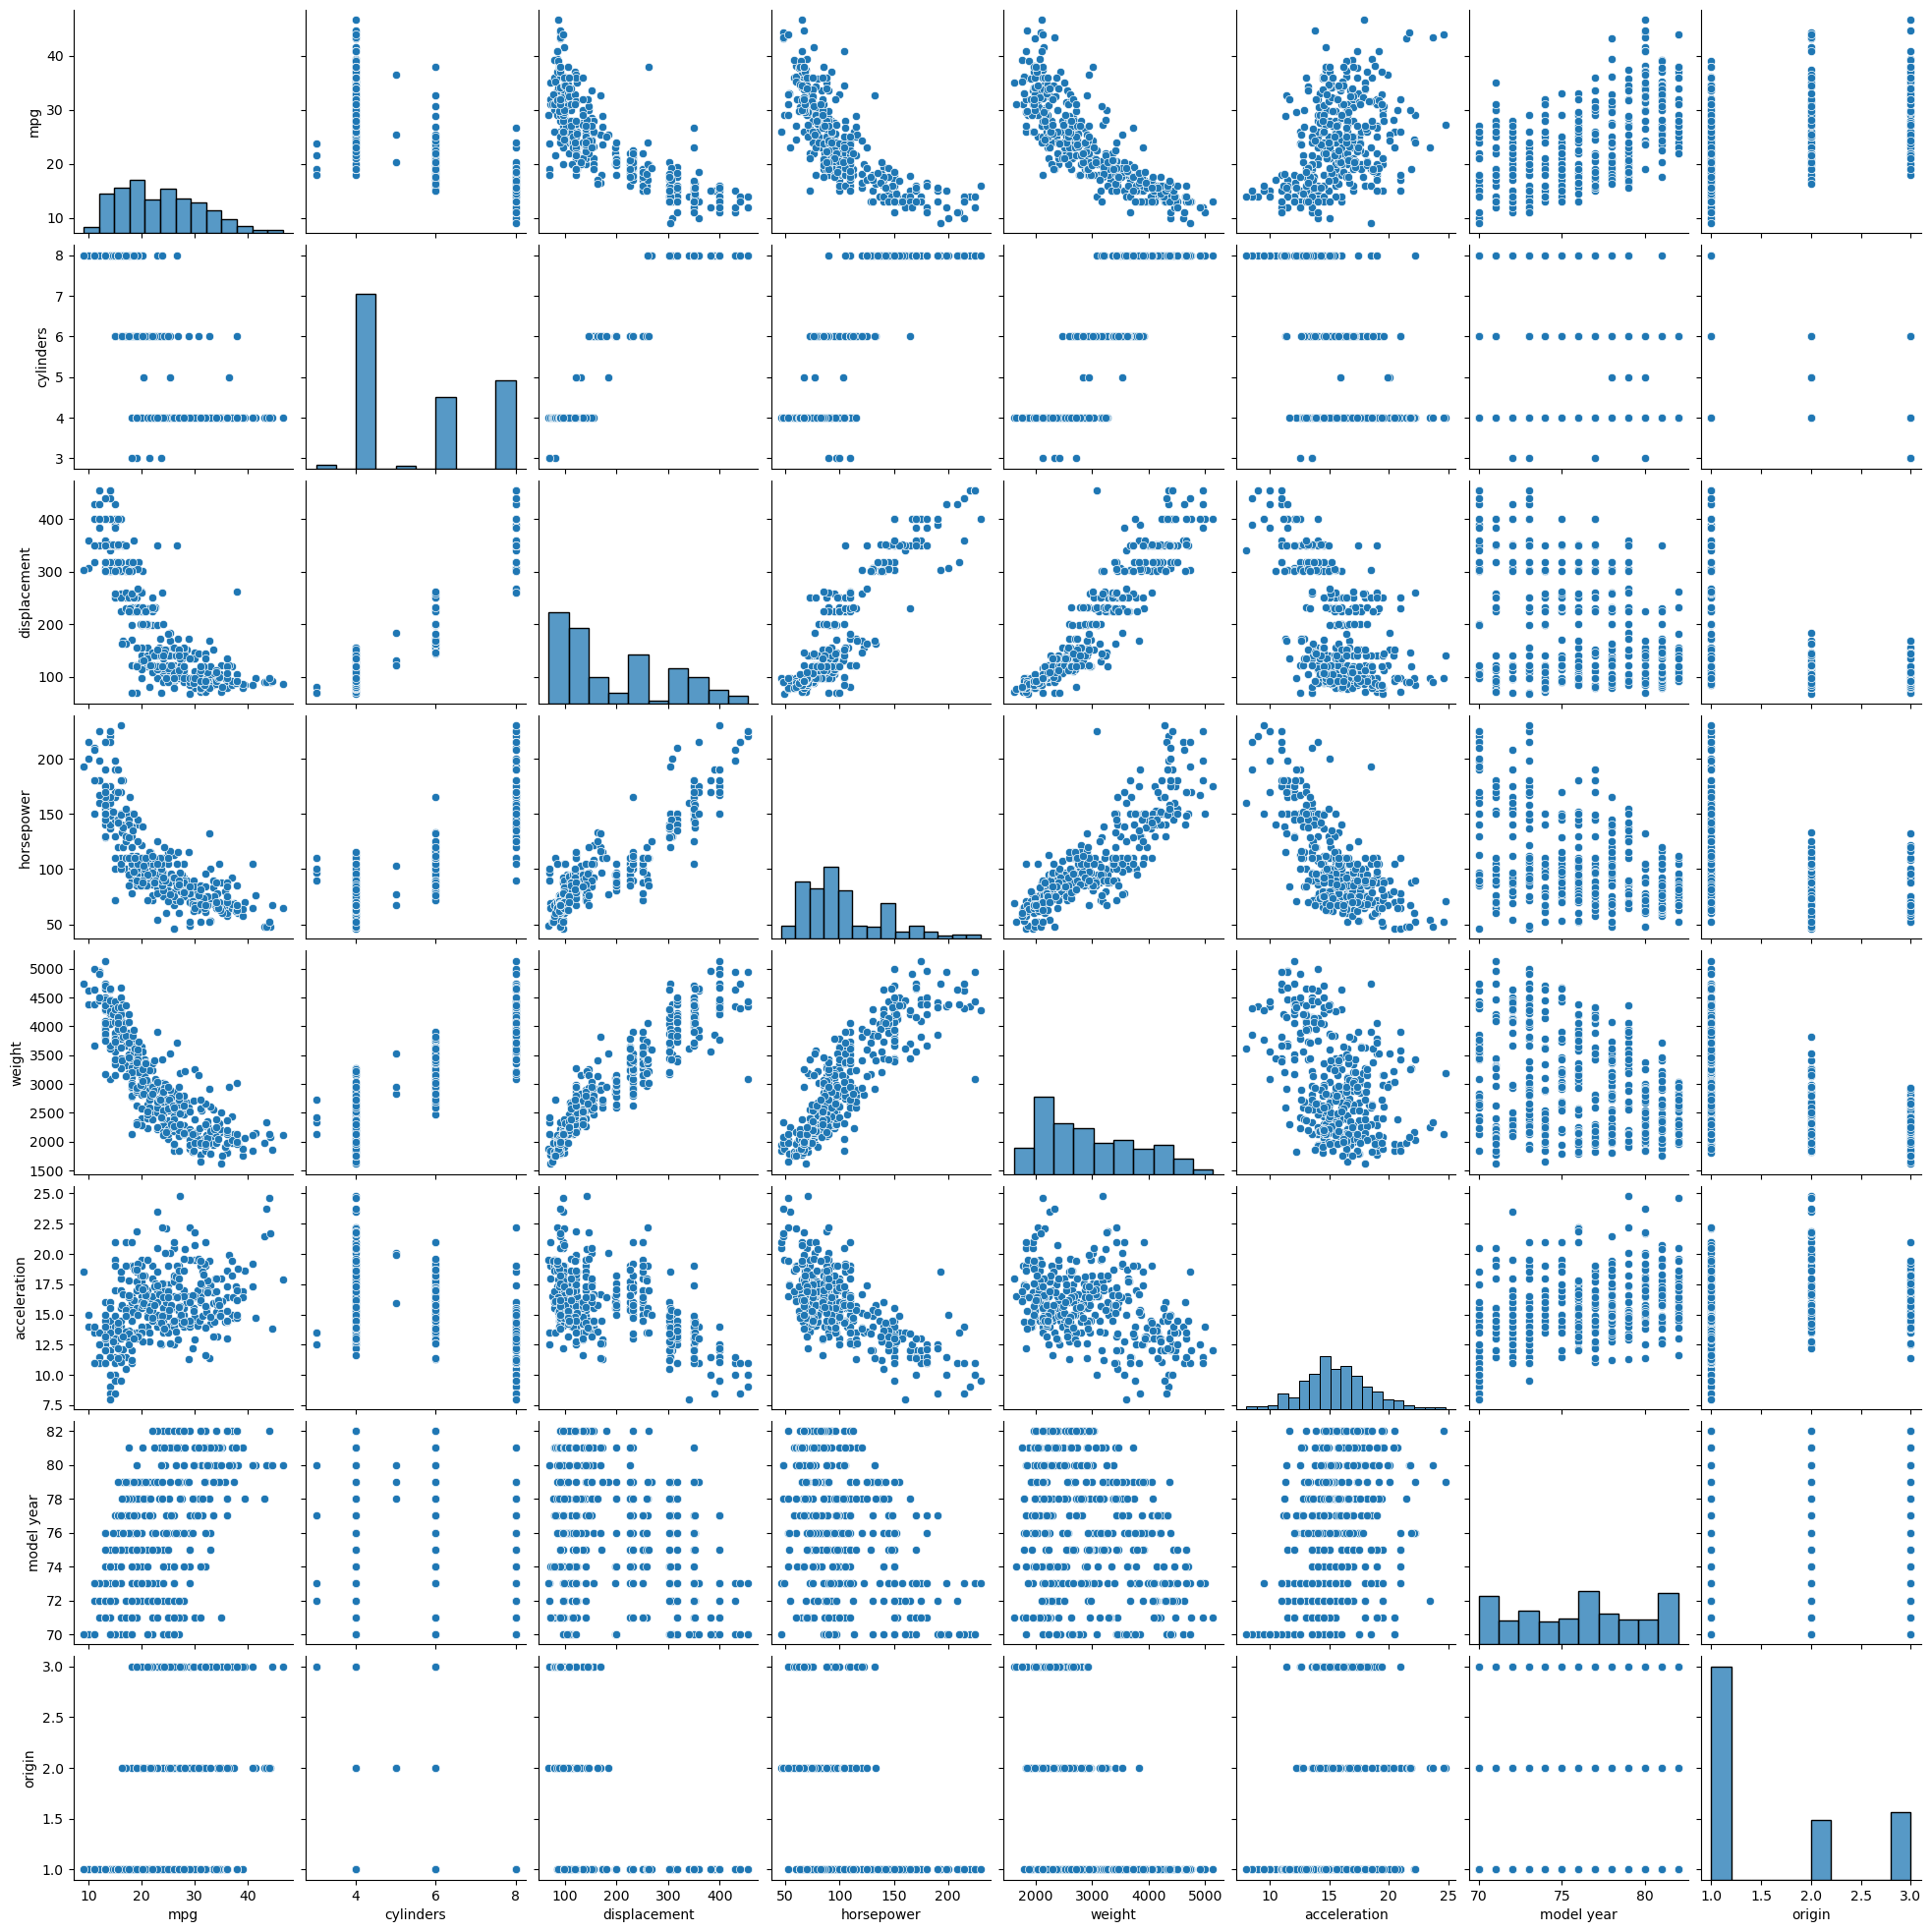

In [71]:
# Multi varient analysis
sns.pairplot(df_num)

<Axes: >

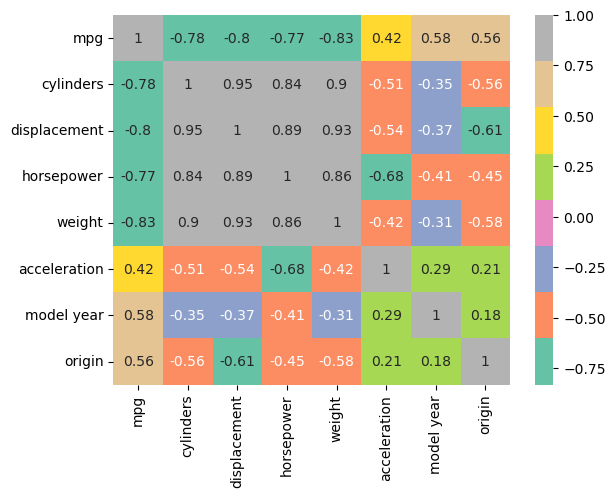

In [72]:
sns.heatmap(df_num.corr(),annot=True,cmap='Set2')

# Observation:
relation between the numerical variable

## Q1. What is the distribution of MPG in the dataset?

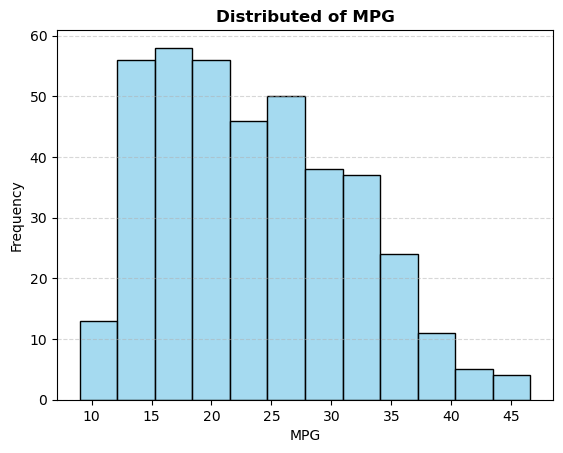

In [51]:
sns.histplot(data = df, x = 'mpg', bins = 12,color='skyblue', edgecolor='black')
plt.title('Distributed of MPG',fontsize = 12, fontweight = 'bold')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.style.use('default')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Observation¶
The histogram shows that most cars have MPG between 15 and 30, while very high MPG values are relatively few.

## Q2. How many cars are from each origin (USA, Europe, Japan)?

In [15]:
df['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [16]:
df['origin'].map({1:'USA', 2:'Europe', 3:'Japan'}).value_counts()

origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

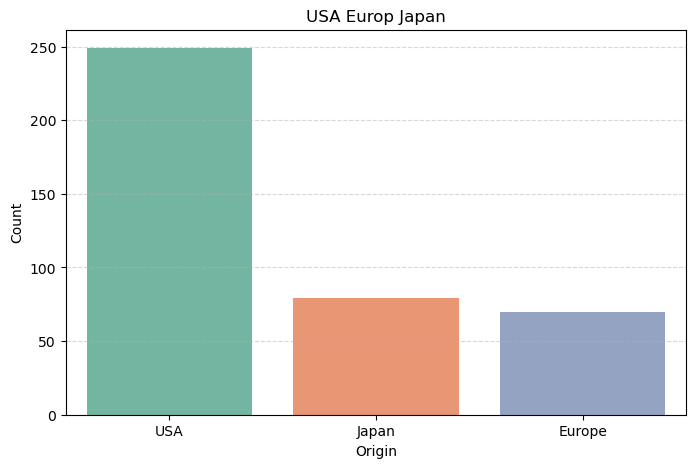

In [17]:
origin_counts = df['origin'].replace({
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
}).value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=origin_counts.index, y=origin_counts.values, hue = origin_counts.index, palette='Set2')
plt.title('USA Europ Japan')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlabel('Origin')
plt.ylabel('Count')
plt.show()

# Observation¶
Most cars are from the 1:USA, followed by 3:Japan, while 2:Europe has the fewest cars.

## Q3. What is proportion of cars are from each origin (USA, Europe, Japan)?

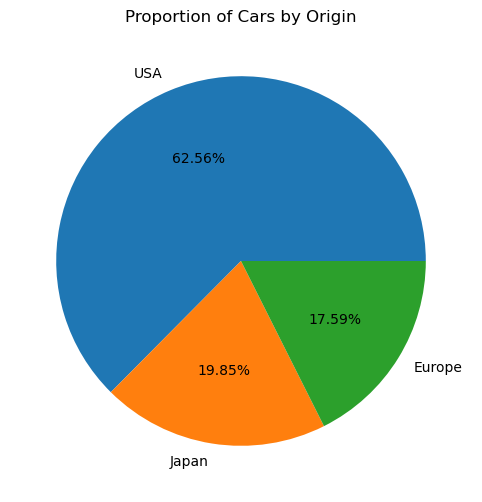

In [18]:
origin_counts = df['origin'].replace({
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
}).value_counts()

plt.figure(figsize=(10,6))
plt.pie(origin_counts.values, labels=origin_counts.index, autopct='%.2f%%')
plt.title('Proportion of Cars by Origin')
plt.show()

## Observation:
- 1:USA is largest proportion of cars, 
- 2:Europe is moderate proportion of cars and
-  3:Japan is smallest proportion of cars

## Q4. What percentage of cars belong to each cylinder category?

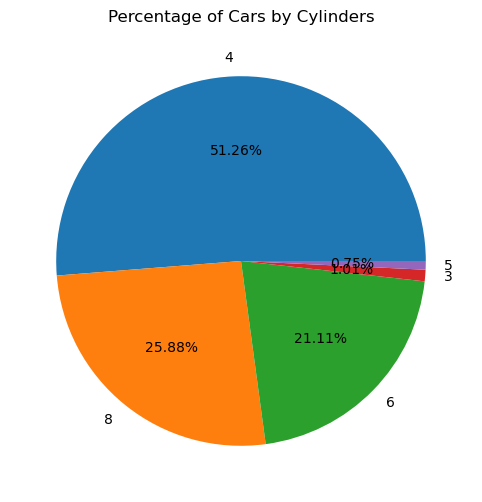

In [20]:
plt.figure(figsize=(10,6))
plt.title('Percentage of Cars by Cylinders')
plt.pie(df['cylinders'].value_counts().values, labels = df['cylinders'].value_counts().index, autopct = '%.2f%%')
plt.show()

Observations
- 4-cylinder cars have the largest share in the dataset.
- 8-cylinder cars are the second most common.
- 6-cylinder cars are also present but fewer than 4- and 8-cylinder cars.
- 3-cylinder and 5-cylinder cars have the smallest share.
The pie chart shows the percentage distribution of cars based on the number of cylinders.

## Q5. What is the relationship between horsepower and weight of cars?

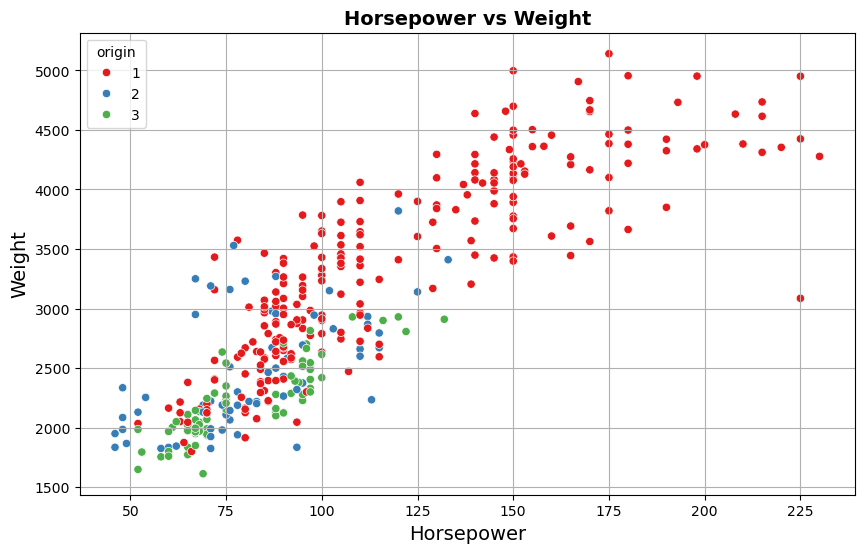

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="horsepower", y="weight",hue = 'origin',palette = 'Set1')
plt.title('Horsepower vs Weight',fontsize = 14, fontweight = 'bold')
plt.xlabel('Horsepower',fontsize = 14, )
plt.ylabel('Weight',fontsize = 14)
plt.grid()
plt.show()

## Q6. How does MPG vary across different numbers of cylinders?

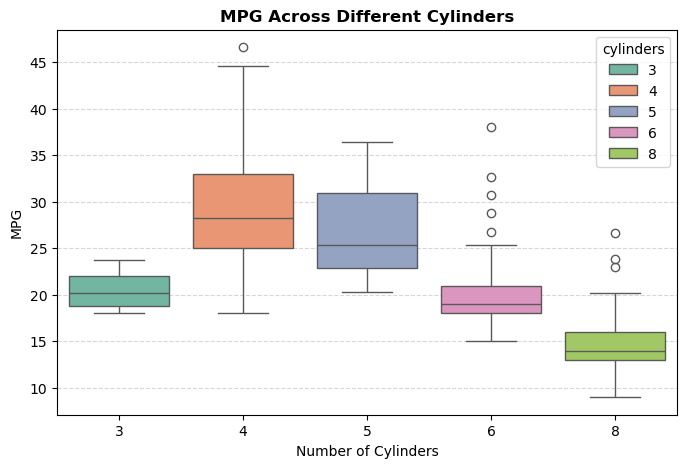

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='cylinders', y='mpg', hue = 'cylinders', palette='Set2')
plt.title('MPG Across Different Cylinders',fontsize = 12, fontweight = 'bold')
plt.xlabel('Number of Cylinders')
plt.ylabel('MPG')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Q7. What are the relationships among horsepower, and acceleration ?

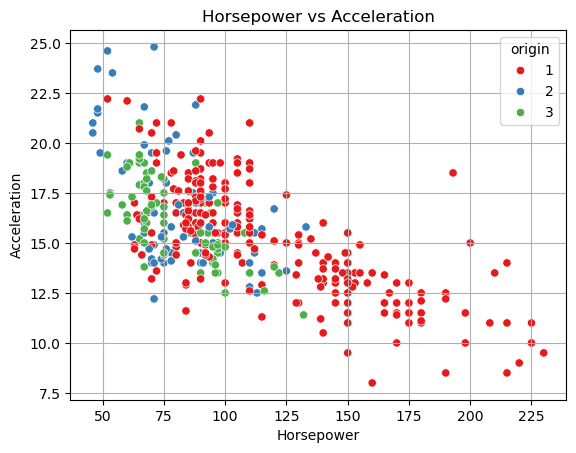

In [28]:
sns.scatterplot(data=df, x="horsepower", y="acceleration",hue = 'origin',palette = 'Set1')
plt.title('Horsepower vs Acceleration')
plt.xlabel('Horsepower')
plt.ylabel('Acceleration')
plt.grid()
plt.show()

## Q8. How does horsepower vary by origin?

C:\Users\akhil\AppData\Local\Temp\ipykernel_11948\3293518507.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin',y='horsepower', palette='Set1')


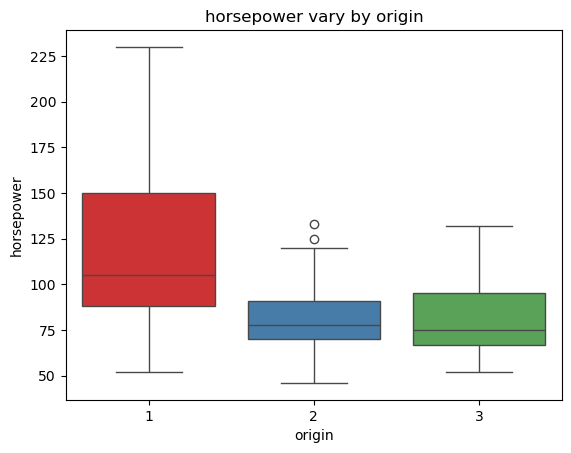

In [57]:
sns.boxplot(data=df, x='origin',y='horsepower', palette='Set1')
plt.title('horsepower vary by origin')
plt.xlabel('origin')
plt.ylabel('horsepower')
plt.show()

## Q9. What is the trend of MPG across different model years?

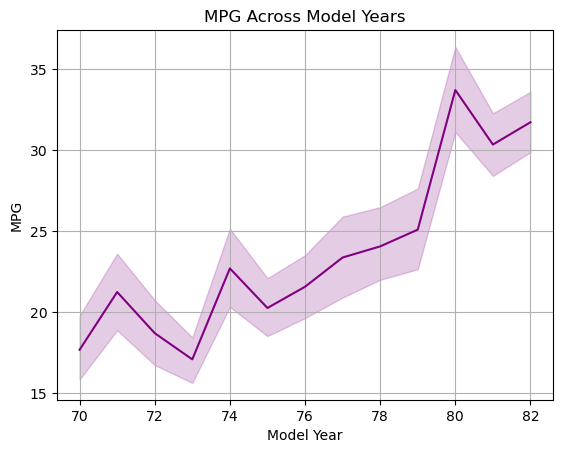

In [39]:
sns.lineplot(data = df, x = 'model year', y = 'mpg',color = 'purple')
plt.title('MPG Across Model Years')
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.grid()
plt.show()

## Q10. What is the distribution of displacement in the dataset?

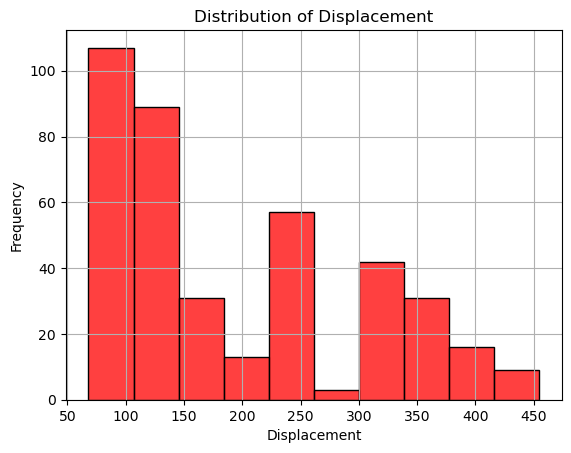

In [40]:
sns.histplot(data = df, x = 'displacement', bins = 10, color = 'red', edgecolor = 'black')
plt.title('Distribution of Displacement')
plt.xlabel('Displacement')
plt.ylabel('Frequency')
plt.grid()
plt.show()

## Q11. How does the weight affect the mpg

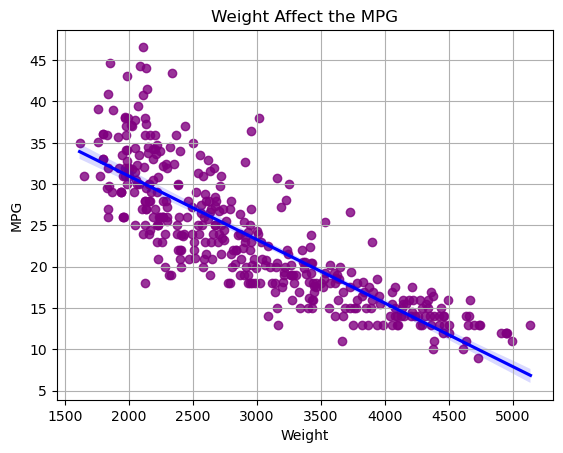

In [43]:
sns.regplot(data=df, x='weight', y='mpg',scatter_kws={'color': 'purple'},line_kws={'color': 'blue'})
plt.title('Weight Affect the MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.grid()
plt.show()

## Q12. What is the relationship between MPG and acceleration?

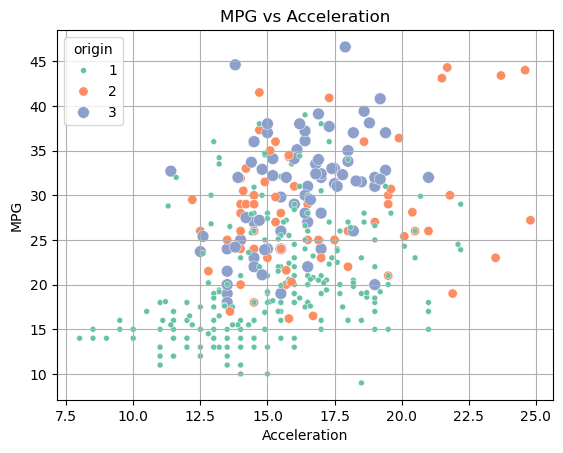

In [45]:
sns.scatterplot(data = df, x = "acceleration", y = "mpg",hue = 'origin',palette = 'Set2',size='origin')
plt.title('MPG vs Acceleration')
plt.xlabel('Acceleration')
plt.ylabel('MPG')
plt.grid()
plt.show()

## Q13. What relationships can be inferred between MPG, horsepower, and weight?

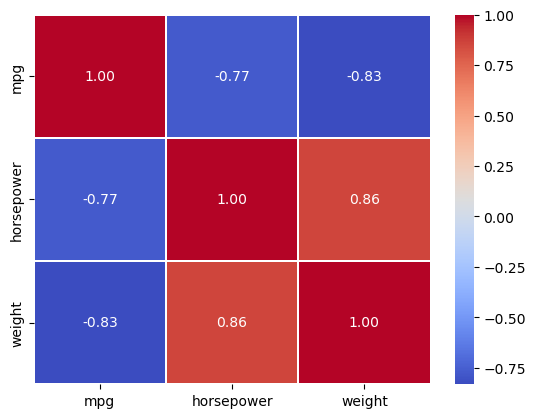

In [46]:
corr = df[['mpg', 'horsepower', 'weight']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.25)
plt.show()

## Q14. What is the distribution of MPG for different car origins?

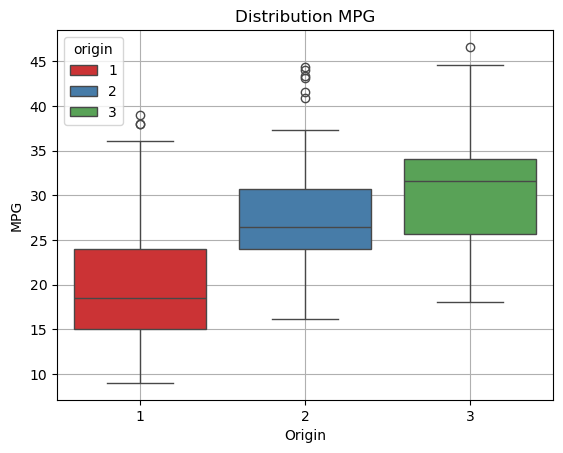

In [47]:
sns.boxplot(data = df, x = 'origin', y = 'mpg',hue = 'origin' , palette= 'Set1')
plt.title('Distribution MPG')
plt.xlabel('Origin')
plt.ylabel('MPG')
plt.grid()
plt.show()

## Q15. What is the distribution of acceleration among various origin of cars?

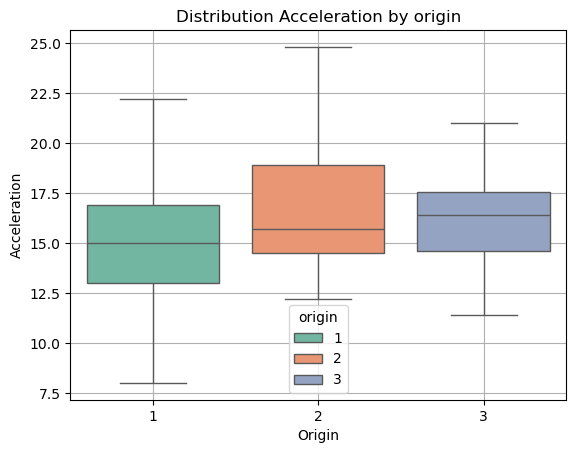

In [48]:
sns.boxplot(data = df, x = 'origin', y = 'acceleration',hue = 'origin' , palette= 'Set2')
plt.title('Distribution Acceleration by origin')
plt.xlabel('Origin')
plt.ylabel('Acceleration')
plt.grid()
plt.show()

## Q16. How does the weight of cars vary by their origin?

C:\Users\akhil\AppData\Local\Temp\ipykernel_11948\1950458319.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='origin', y='weight', data=df,palette='Set2')


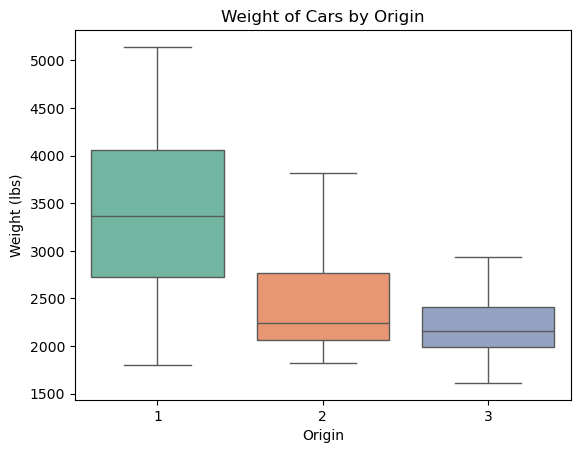

In [53]:
sns.boxplot(x='origin', y='weight', data=df,palette='Set2')

plt.title('Weight of Cars by Origin')
plt.xlabel('Origin')
plt.ylabel('Weight (lbs)')
plt.show()

## Q17. What is the relationship between MPG and horsepower?

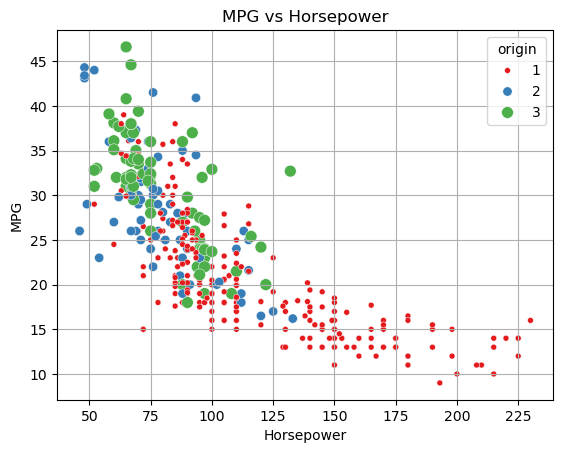

In [50]:
sns.scatterplot(data=df, x="horsepower", y="mpg",hue = 'origin', palette = 'Set1',size ='origin')
plt.title('MPG vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.grid()
plt.show()